In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read the data and display the first 5 rows

In [ ]:
data=pd.read_csv("Data\Online_Retail.csv")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [23]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## check the Data from Duplicates and Remove the Duplicates

In [25]:
print(data.duplicated().sum())

5268


In [26]:
data.drop_duplicates(inplace=True)

In [27]:
print(data.duplicated().sum())

0


In [28]:
data.shape

(536641, 8)

## Check The Data from missing Values and deal  with them

In [29]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [30]:
data=data.dropna(subset=['CustomerID'])

In [31]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Remove  InvoiceNo  that start with C: cancelled orders

In [32]:
data=data[~data['InvoiceNo'].astype(str).str.startswith('c')]

## Remove negative Quantites

In [33]:
data=data[data['Quantity']>0]

In [35]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,15287.734822
std,181.588420,22.240725,1713.567773
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


## Detect outliers and deal with them 

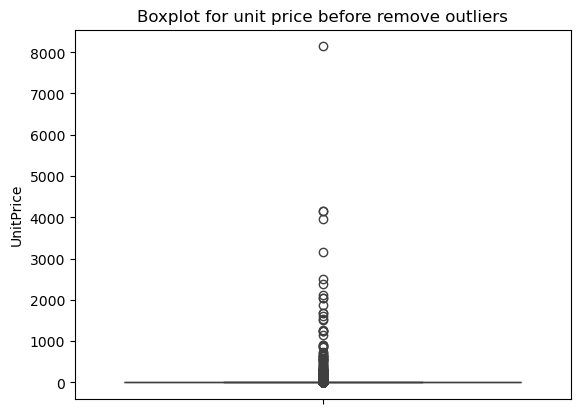

In [36]:
sns.boxplot(data=data["UnitPrice"])
plt.title("Boxplot for unit price before remove outliers")
plt.show()

In [41]:
Q1=data['UnitPrice'].quantile(.25)
Q3=data['UnitPrice'].quantile(.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
data=data[(data['UnitPrice']>=lower) & (data['UnitPrice']<=upper)]


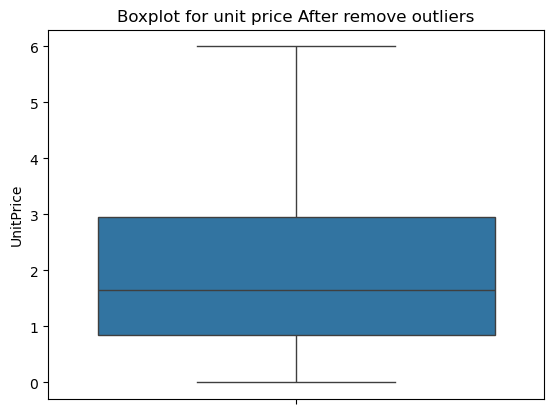

In [42]:
sns.boxplot(data=data["UnitPrice"])
plt.title("Boxplot for unit price After remove outliers")
plt.show()

In [43]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,351813.000000,351813.000000,351813.000000
mean,14.262904,2.046383,15301.662943
std,191.786225,1.406592,1713.974729
min,1.000000,0.000000,12346.000000
25%,2.000000,0.850000,13969.000000
50%,6.000000,1.650000,15181.000000
75%,12.000000,2.950000,16805.000000
max,80995.000000,6.000000,18287.000000


In [44]:
data['TotalPrice']=data['Quantity'] * data['UnitPrice']

## convert date column and get useful time features

In [46]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data.info()

C:\Users\alamia\AppData\Local\Temp\ipykernel_13432\1879869052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


<class 'pandas.core.frame.DataFrame'>
Index: 351813 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    351813 non-null  object        
 1   StockCode    351813 non-null  object        
 2   Description  351813 non-null  object        
 3   Quantity     351813 non-null  int64         
 4   InvoiceDate  351813 non-null  datetime64[ns]
 5   UnitPrice    351813 non-null  float64       
 6   CustomerID   351813 non-null  float64       
 7   Country      351813 non-null  object        
 8   TotalPrice   351813 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 26.8+ MB


In [ ]:
data['YearMonth'] = data['InvoiceDate'].dt.to_period('M')
data['Day'] = data['InvoiceDate'].dt.day
data['DayOfWeek'] = data['InvoiceDate'].dt.day_name()
data['Hour'] = data['InvoiceDate'].dt.hour

In [50]:
data.sample(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,Day,DayOfWeek,Hour
78816,542898,22722,SET OF 6 SPICE TINS PANTRY DESIGN,2,2011-02-01 14:01:00,3.95,16110.0,United Kingdom,7.90,2011-02,1,Tuesday,14
526722,580676,22696,WICKER WREATH LARGE,5,2011-12-05 14:39:00,1.95,17817.0,United Kingdom,9.75,2011-12,5,Monday,14
329948,565859,21703,BAG 125g SWIRLY MARBLES,12,2011-09-07 14:40:00,0.42,16818.0,United Kingdom,5.04,2011-09,7,Wednesday,14
189519,553156,22555,PLASTERS IN TIN STRONGMAN,1,2011-05-13 14:58:00,1.65,17841.0,United Kingdom,1.65,2011-05,13,Friday,14


In [ ]:
data.to_csv('Data\online_retail_cleaned.csv', index=False)